# FairFace Pipeline Evaluation

This notebook tests whether the complete face-detection, skin-sampling,
and recommendation pipeline finishes successfully on a balanced sample
of 140 adult FairFace images (20 from each of seven labelled groups).

**Important:** FairFace does not provide correct foundation labels. This
notebook measures pipeline completion, not shade-match accuracy. Group
rates are descriptive diagnostics and are not proof of fairness.


## 1. Setup


In [1]:
from pathlib import Path
import os
import subprocess
import sys

REPOSITORY_URL = "https://github.com/amafteeva/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-.git"


def find_project_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    return None


project_root = find_project_root(Path.cwd())

if project_root is None and "google.colab" in sys.modules:
    project_root = Path("/content/foundation-shade-recommender")
    if not project_root.exists():
        subprocess.run(["git", "clone", REPOSITORY_URL, str(project_root)], check=True)

if project_root is None:
    raise FileNotFoundError("Run this notebook from inside the project folder.")

os.chdir(project_root)

# Connect the local `foundation_matcher` package (src/ layout) so the
# imports below resolve even if the editable install has not been run.
src_path = project_root / "src"
if src_path.is_dir() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Install the package and its dependencies. Non-fatal: if a dependency
# wheel is unavailable the local package is still importable via src_path.
result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "."],
    check=False,
)
if result.returncode != 0:
    print("Warning: `pip install -e .` failed; using src/ on sys.path instead.")

import importlib.util

if importlib.util.find_spec("foundation_matcher") is None:
    raise ModuleNotFoundError(
        f"foundation_matcher not found. Expected package at {src_path}."
    )

print("Project root:", project_root)
print("foundation_matcher connected from:", src_path)


Project root: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-
foundation_matcher connected from: /Users/mafteevaalina/Downloads/capstone/Predictive-beauty-analysis-using-computer-vision-and-machine-learning-/src


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from IPython.display import display

from foundation_matcher.config import FAIRFACE_RACE_NAMES
from foundation_matcher.data import load_foundation_catalog
from foundation_matcher.evaluation import (
    evaluate_face_pipeline,
    evaluate_group_completion_disparity,
    select_balanced_adult_samples,
    simulate_colour_robustness,
    summarize_group_completion,
)
from foundation_matcher.face import (
    create_face_landmarker,
    download_face_landmarker,
)
from foundation_matcher.visualization import (
    plot_group_completion,
    plot_previews,
)


## 2. Build one reproducible 140-image sample

The original notebook selected 35 images and later asserted that the same
object contained 140. This version selects 20 images per group once and
verifies the final total before evaluation.


In [3]:
products = load_foundation_catalog()
model_path = download_face_landmarker("models/face_landmarker.task")

fairface_stream = load_dataset(
    "HuggingFaceM4/FairFace",
    "0.25",
    split="validation",
    streaming=True,
).shuffle(seed=42, buffer_size=2_000)

balanced_samples = select_balanced_adult_samples(
    fairface_stream,
    samples_per_group=20,
)

assert len(balanced_samples) == 140
print("Balanced evaluation images:", len(balanced_samples))


Balanced evaluation images: 140


## 3. Run the complete pipeline

A run is successful only when a face is detected, skin colour is
extracted, and five recommendations are returned. Individual failures
are recorded instead of stopping the whole experiment.


In [4]:
landmarker = create_face_landmarker(model_path)
try:
    evaluation, previews = evaluate_face_pipeline(
        balanced_samples,
        FAIRFACE_RACE_NAMES,
        landmarker,
        products,
        image_directory="outputs/fairface_test_140",
        top_n=5,
        preview_limit=14,
    )
finally:
    landmarker.close()

overall_completion = evaluation["pipeline_success"].mean()
print(f"Successful runs: {evaluation['pipeline_success'].sum()}/{len(evaluation)}")
print(f"Overall pipeline completion: {overall_completion:.1%}")

output_path = Path("outputs/tables/fairface_evaluation_140.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)
evaluation.to_csv(output_path, index=False)
print("Saved:", output_path)


W0000 00:00:1788864478.755344 1215258 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1788864478.877524 1215258 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1788864478.888742 1215261 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788864478.899517 1215261 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Successful runs: 122/140
Overall pipeline completion: 87.1%
Saved: outputs/tables/fairface_evaluation_140.csv


## 4. Inspect completion by group and failure reason


,group,tested,successful,success_rate
0,Black,20,18,90.0%
1,East Asian,20,17,85.0%
2,Indian,20,16,80.0%
3,Latino/Hispanic,20,18,90.0%
4,Middle Eastern,20,17,85.0%
5,Southeast Asian,20,18,90.0%
6,White,20,18,90.0%


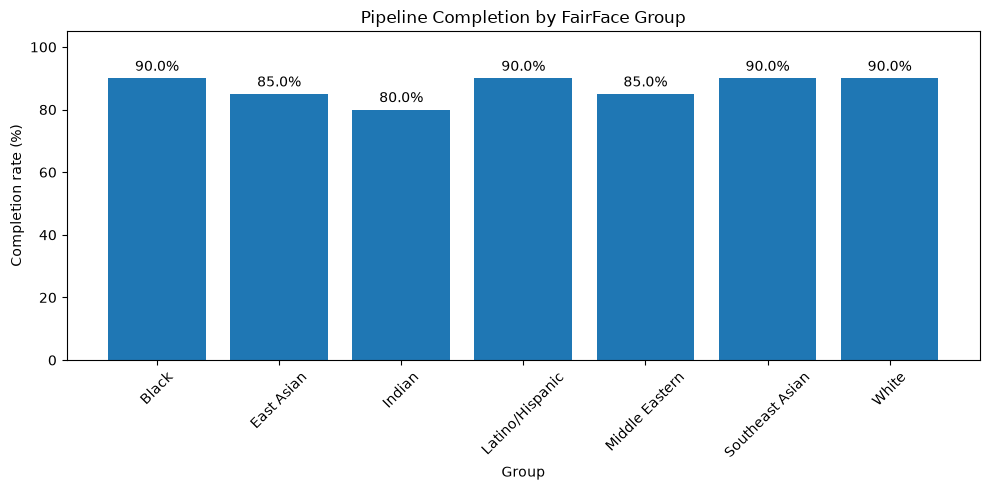

In [5]:
group_summary = summarize_group_completion(evaluation)
display(group_summary.style.format({"success_rate": "{:.1f}%"}))

plot_group_completion(group_summary)
plt.show()


## 4b. Is the completion-rate gap statistically significant?

The table above shows a spread between groups (e.g. the lowest- and
highest-completing groups), but with only 20 images per group that spread
could easily be random noise rather than a real disparity. This
permutation test shuffles the group labels 10,000 times and checks how
often chance alone produces a spread at least as large as the one
actually observed — a low p-value means the observed gap is unlikely to
be chance; a high p-value means it's consistent with noise at this
sample size.


In [6]:
disparity = evaluate_group_completion_disparity(
    evaluation,
    number_of_permutations=10_000,
    random_state=42,
)

print(
    "Observed completion-rate spread: "
    f"{disparity['observed_completion_rate_spread']:.1%}"
)
print(f"Permutation p-value: {disparity['permutation_p_value']:.4f}")

if disparity["permutation_p_value"] < 0.05:
    print(
        "This spread is larger than random group-label shuffles typically "
        "produce (p < 0.05) — worth investigating further, ideally with a "
        "larger sample."
    )
else:
    print(
        "This spread is consistent with random noise at this sample size "
        "(p >= 0.05) — not strong evidence of a real group disparity on "
        "its own."
    )


Observed completion-rate spread: 10.0%
Permutation p-value: 0.9802
This spread is consistent with random noise at this sample size (p >= 0.05) — not strong evidence of a real group disparity on its own.


Failed runs: 18


,image_id,group,error
4,4,Latino/Hispanic,No face was detected.
19,19,Middle Eastern,No face was detected.
30,30,East Asian,No face was detected.
34,34,Southeast Asian,No face was detected.
35,35,Latino/Hispanic,No face was detected.
53,53,Middle Eastern,No face was detected.
60,60,Black,No face was detected.
64,64,White,No face was detected.
75,75,East Asian,No face was detected.
87,87,Black,No face was detected.


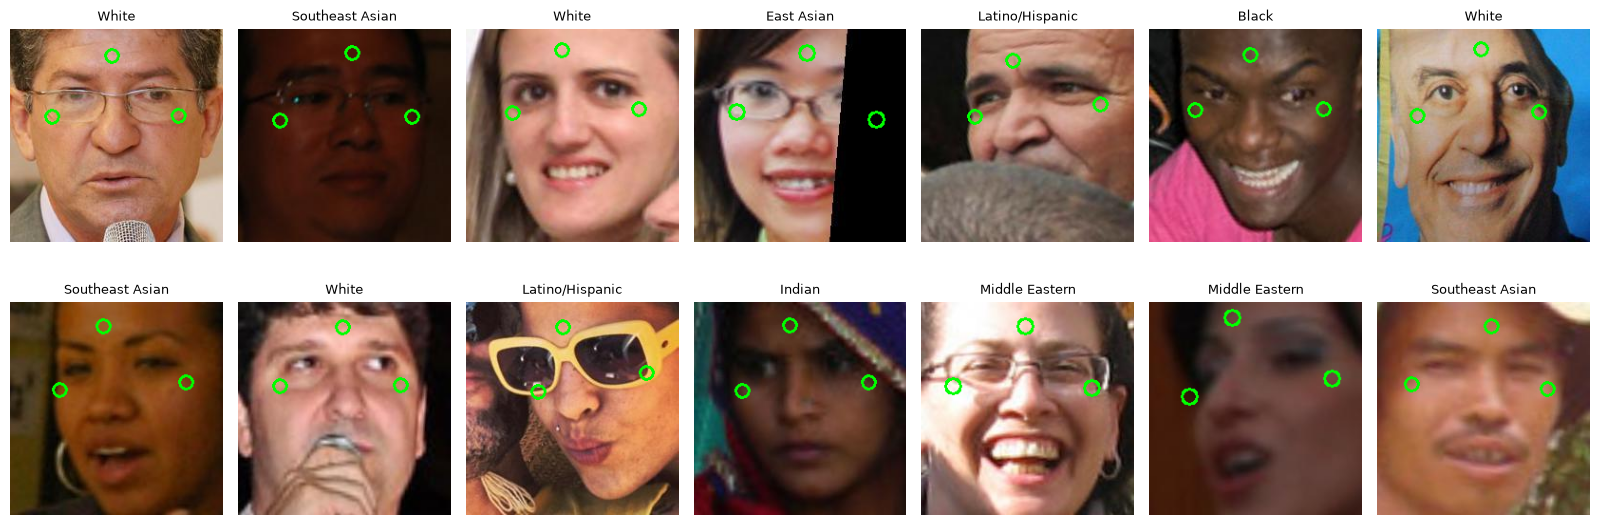

In [7]:
failures = evaluation.loc[
    ~evaluation["pipeline_success"],
    ["image_id", "group", "error"],
]

print("Failed runs:", len(failures))
display(failures if not failures.empty else pd.DataFrame({"status": ["No failures"]}))

if previews:
    plot_previews(previews)
    plt.show()


## 5. Simulated colour robustness

This second experiment starts with a catalogue LAB colour, adds a small
synthetic perturbation, and checks what the recommender retrieves.

Exact-row recovery is not the same as perceptual quality because different
brands can share identical or nearly identical digital colours. Delta E
thresholds are therefore reported separately.


In [8]:
robustness = simulate_colour_robustness(
    products,
    number_of_tests=500,
    random_state=42,
)

robustness_table = pd.Series(robustness, name="value").to_frame()
display(robustness_table.round(3))


,value
number_of_tests,500.000
exact_top1_recovery,0.298
exact_top5_recovery,0.654
median_top1_delta_e,1.783
mean_top1_delta_e,1.730
top1_within_delta_e_2,0.562
top1_within_delta_e_5,0.976
top5_contains_delta_e_2,0.862


## 6. What this evaluation can support

**Supported conclusion:** report the overall and group-specific pipeline
completion rates for this sample, with failure reasons and sample sizes,
along with whether the observed group-to-group spread in completion rate
is statistically distinguishable from random noise at this sample size
(section 4b) or perceptual ranking stability under simulated lighting
noise (section 5).

**Unsupported conclusion:** do not call these results match accuracy,
precision, recall, or F1. Those metrics require ground-truth foundation
labels. A non-significant permutation-test result (section 4b) is not
proof of fairness either — it means this sample is too small to
distinguish the observed gap from chance, not that no real gap exists. A
stronger study would collect professionally labelled matches, calibrated
images, repeated lighting conditions, and enough participants for
uncertainty estimates and subgroup analysis.
